Online News Popularity Prediction Model


In [1]:
#import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.metrics import(
  mean_absolute_error,
  mean_squared_error,
  r2_score,
  root_mean_squared_error
)

In [2]:
#load dataset

df =pd.read_csv('OnlineNewsPopularity.csv')

In [3]:
#understand dataset

df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [4]:
df.tail()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
39639,http://mashable.com/2014/12/27/samsung-app-aut...,8.0,11.0,346.0,0.529052,1.0,0.684783,9.0,7.0,1.0,...,0.100000,0.75,-0.260000,-0.5,-0.125000,0.100000,0.000000,0.400000,0.000000,1800
39640,http://mashable.com/2014/12/27/seth-rogen-jame...,8.0,12.0,328.0,0.696296,1.0,0.885057,9.0,7.0,3.0,...,0.136364,0.70,-0.211111,-0.4,-0.100000,0.300000,1.000000,0.200000,1.000000,1900
39641,http://mashable.com/2014/12/27/son-pays-off-mo...,8.0,10.0,442.0,0.516355,1.0,0.644128,24.0,1.0,12.0,...,0.136364,0.50,-0.356439,-0.8,-0.166667,0.454545,0.136364,0.045455,0.136364,1900
39642,http://mashable.com/2014/12/27/ukraine-blasts/,8.0,6.0,682.0,0.539493,1.0,0.692661,10.0,1.0,1.0,...,0.062500,0.50,-0.205246,-0.5,-0.012500,0.000000,0.000000,0.500000,0.000000,1100
39643,http://mashable.com/2014/12/27/youtube-channel...,8.0,10.0,157.0,0.701987,1.0,0.846154,1.0,1.0,0.0,...,0.100000,0.50,-0.200000,-0.2,-0.200000,0.333333,0.250000,0.166667,0.250000,1300


In [5]:
df.describe()

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,946.000000
50%,339.000000,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,542.000000,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,2800.000000
max,731.000000,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


In [6]:
df.shape

(39644, 61)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

In [8]:
df.columns

Index(['url', ' timedelta', ' n_tokens_title', ' n_tokens_content',
       ' n_unique_tokens', ' n_non_stop_words', ' n_non_stop_unique_tokens',
       ' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos',
       ' average_token_length', ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sent

In [9]:
#check missing values

df.isnull().sum()

url                              0
 timedelta                       0
 n_tokens_title                  0
 n_tokens_content                0
 n_unique_tokens                 0
                                ..
 title_subjectivity              0
 title_sentiment_polarity        0
 abs_title_subjectivity          0
 abs_title_sentiment_polarity    0
 shares                          0
Length: 61, dtype: int64

In [10]:
df = df.rename(columns={' shares':'shares'})

In [11]:
df.dtypes

url                               object
 timedelta                       float64
 n_tokens_title                  float64
 n_tokens_content                float64
 n_unique_tokens                 float64
                                  ...   
 title_subjectivity              float64
 title_sentiment_polarity        float64
 abs_title_subjectivity          float64
 abs_title_sentiment_polarity    float64
shares                             int64
Length: 61, dtype: object

In [12]:
#remove unnecessery columns

df= df.drop(columns=['url'])

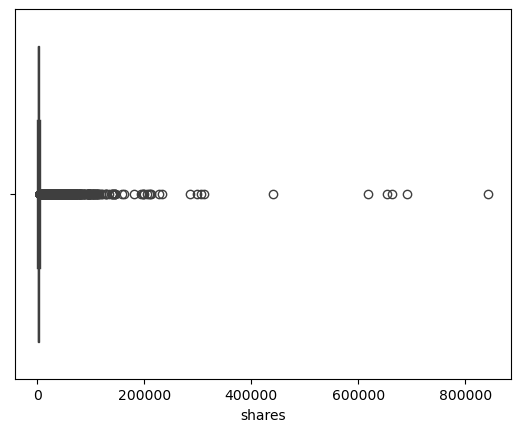

In [13]:
#visualize outliers

sns.boxplot(x=df["shares"])
plt.show()

In [14]:
#detect outliers

Q1 = df['shares'].quantile(0.25)
Q3 = df['shares'].quantile(0.75)

IQR = Q3-Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR


outliers = df[
    (df['shares'] < lower_limit) |
    (df['shares'] > upper_limit)
    ]

In [15]:
print(outliers.shape)

(4541, 60)


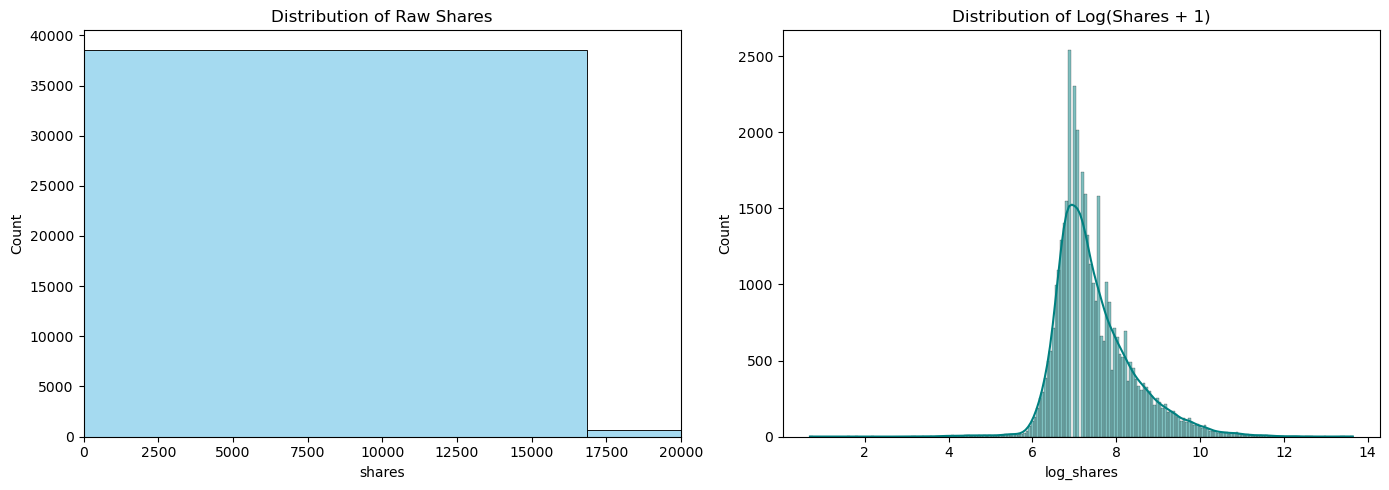

In [19]:
#use log transformation 

df['log_shares'] = np.log1p(df['shares'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original shares (with cap for visualization)
sns.histplot(df['shares'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Raw Shares')
axes[0].set_xlim(0, 20000)  # capped to see peak

# Log-transformed shares
sns.histplot(df['log_shares'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution of Log(Shares + 1)')

plt.tight_layout()
plt.show()

In [17]:
df.head()

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,log_shares
0,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,...,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593,6.386879
1,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,...,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711,6.568078
2,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,...,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500,7.313887
3,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,...,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200,7.090910
4,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,...,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505,6.226537


In [18]:
#feature target separation

X = df.drop(columns=['shares','log_shares'])

In [19]:
y = df['log_shares']

In [20]:
X

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity
0,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,...,0.378636,0.100000,0.70,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500
1,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,...,0.286915,0.033333,0.70,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000
2,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,...,0.495833,0.100000,1.00,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000
3,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,...,0.385965,0.136364,0.80,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000
4,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,...,0.411127,0.033333,1.00,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,8.0,11.0,346.0,0.529052,1.0,0.684783,9.0,7.0,1.0,1.0,...,0.333791,0.100000,0.75,-0.260000,-0.500,-0.125000,0.100000,0.000000,0.400000,0.000000
39640,8.0,12.0,328.0,0.696296,1.0,0.885057,9.0,7.0,3.0,48.0,...,0.374825,0.136364,0.70,-0.211111,-0.400,-0.100000,0.300000,1.000000,0.200000,1.000000
39641,8.0,10.0,442.0,0.516355,1.0,0.644128,24.0,1.0,12.0,1.0,...,0.307273,0.136364,0.50,-0.356439,-0.800,-0.166667,0.454545,0.136364,0.045455,0.136364
39642,8.0,6.0,682.0,0.539493,1.0,0.692661,10.0,1.0,1.0,0.0,...,0.236851,0.062500,0.50,-0.205246,-0.500,-0.012500,0.000000,0.000000,0.500000,0.000000


In [21]:
y

0        6.386879
1        6.568078
2        7.313887
3        7.090910
4        6.226537
           ...   
39639    7.496097
39640    7.550135
39641    7.550135
39642    7.003974
39643    7.170888
Name: log_shares, Length: 39644, dtype: float64

In [22]:
#train test split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [23]:
y

0        6.386879
1        6.568078
2        7.313887
3        7.090910
4        6.226537
           ...   
39639    7.496097
39640    7.550135
39641    7.550135
39642    7.003974
39643    7.170888
Name: log_shares, Length: 39644, dtype: float64

In [24]:
#scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
#model training

In [26]:
#linear regression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [27]:
#make predictions

y_pred_lr = lr_pipeline.predict(X_test)

In [28]:
#evaluation

mse_lr = mean_squared_error(y_test,y_pred_lr)
mae_lr = mean_absolute_error(y_test,y_pred_lr)
r2_lr = r2_score(y_test,y_pred_lr)
rmse_lr = root_mean_squared_error(y_test,y_pred_lr)

In [29]:
print("Linear Regression")
print("MSE :",mse_lr)
print("MAE :",mae_lr)
print("R2 Score :",r2_lr)
print("RMSE :",rmse_lr)

Linear Regression
MSE : 0.7481347682465365
MAE : 0.6441472629267467
R2 Score : 0.1272401715918421
RMSE : 0.8649478413445151


In [30]:
#svr

svr_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',SVR())
])
svr_pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0


In [31]:
#prediction

y_pred_svr = svr_pipeline.predict(X_test)

In [32]:
#evaluation

mse_svr = mean_squared_error(y_test,y_pred_svr)
mae_svr = mean_absolute_error(y_test,y_pred_svr)
r2_svr = r2_score(y_test,y_pred_svr)
rmse_svr = root_mean_squared_error(y_test,y_pred_svr)

In [33]:
print("SVR")
print("MSE:",mse_svr)
print("MAE:",mae_svr)
print("R2_score:",r2_svr)
print("RMSE:",rmse_svr)

SVR
MSE: 0.7495864229565058
MAE: 0.6171335372150708
R2_score: 0.12554669874529845
RMSE: 0.865786592040155


In [34]:
#randomforrestregresser

rft_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model' ,RandomForestRegressor())
])
rft_pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


In [35]:
#predict

y_pred_rft = rft_pipeline.predict(X_test)

In [36]:
#evaluate

mse_rft = mean_squared_error(y_test,y_pred_rft)
mae_rft = mean_absolute_error(y_test,y_pred_rft)
r2_rft = r2_score(y_test,y_pred_rft)
rmse_rft = root_mean_squared_error(y_test,y_pred_rft)

In [37]:
print("RandomForestRegresser")
print("MSE:",mse_rft)
print("MAE:",mae_rft)
print("R2_Score:",r2_rft)
print("RMSE:",rmse_rft)

RandomForestRegresser
MSE: 0.7167496192113382
MAE: 0.636055644235034
R2_Score: 0.1638534910753413
RMSE: 0.8466106656612225


In [38]:
#GradientBoostingRegressor

gbr_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',GradientBoostingRegressor())
])
gbr_pipeline.fit(X_train,y_train)


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0


In [39]:
#predict

y_pred_gbr = gbr_pipeline.predict(X_test)

In [40]:
#evaluate

mse_gbr = mean_squared_error(y_test,y_pred_gbr)
mae_gbr = mean_absolute_error(y_test,y_pred_gbr)
r2_gbr = r2_score(y_test,y_pred_gbr)
rmse_gbr = root_mean_squared_error(y_test,y_pred_gbr)

In [41]:
print("GradientBoostingRegresser")
print("MSE:",mse_gbr)
print("MAE:",mae_gbr)
print("R2_Score:",r2_gbr)
print("RMSE:",rmse_gbr)


GradientBoostingRegresser
MSE: 0.7098899976700682
MAE: 0.627095030987196
R2_Score: 0.17185579543734208
RMSE: 0.8425497004153928


In [42]:
#AdaBoostRegressor

abr_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',AdaBoostRegressor())
])   
abr_pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,None
,n_estimators,50
,learning_rate,1.0
,loss,'linear'


In [43]:
#predict

y_pred_abr=abr_pipeline.predict(X_test)

In [44]:
#evaluate

mse_abr = mean_squared_error(y_test,y_pred_abr)
mae_abr = mean_absolute_error(y_test,y_pred_abr)
r2_abr = r2_score(y_test,y_pred_abr)
rmse_abr = root_mean_squared_error(y_test,y_pred_abr)
print("AdaBoostRegresser")
print("MSE:",mse_abr)
print("MAE:",mae_abr)
print("R2_Score:",r2_abr)
print("RMSE:",rmse_abr)

AdaBoostRegresser
MSE: 1.15096315838479
MAE: 0.8807166790543395
R2_Score: -0.34269178662874067
RMSE: 1.0728295103998537


In [45]:
#hyperparameter tuning

gbr_param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5]
}

gbr_grid = GridSearchCV(
    estimator=gbr_pipeline,
    param_grid=gbr_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

gbr_grid.fit(X_train, y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [46]:
#hyperparameter tuning - RandomForestRegressor

rft_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [2, 5]
}

rft_grid = GridSearchCV(
    estimator=rft_pipeline,
    param_grid=rft_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rft_grid.fit(X_train, y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'model__max_depth': [10, 20], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [47]:
y_pred_rft_tuned = rft_grid.best_estimator_.predict(X_test)

mse_rft_tuned = mean_squared_error(y_test, y_pred_rft_tuned)
mae_rft_tuned = mean_absolute_error(y_test, y_pred_rft_tuned)
r2_rft_tuned = r2_score(y_test, y_pred_rft_tuned)
rmse_rft_tuned = root_mean_squared_error(y_test, y_pred_rft_tuned)

print("RandomForestRegressor (Tuned)")
print("Best Params:", rft_grid.best_params_)
print("MSE:", mse_rft_tuned)
print("MAE:", mae_rft_tuned)
print("R2_Score:", r2_rft_tuned)
print("RMSE:", rmse_rft_tuned)

RandomForestRegressor (Tuned)
Best Params: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}
MSE: 0.7108522458701365
MAE: 0.6315851786638924
R2_Score: 0.17073325494113434
RMSE: 0.8431205405338768


In [48]:
#hyperparameter tuning - AdaBoostRegressor

abr_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.5]
}

abr_grid = GridSearchCV(
    estimator=abr_pipeline,
    param_grid=abr_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

abr_grid.fit(X_train, y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'model__learning_rate': [0.01, 0.1, ...], 'model__n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [49]:
y_pred_abr_tuned = abr_grid.best_estimator_.predict(X_test)

mse_abr_tuned = mean_squared_error(y_test, y_pred_abr_tuned)
mae_abr_tuned = mean_absolute_error(y_test, y_pred_abr_tuned)
r2_abr_tuned = r2_score(y_test, y_pred_abr_tuned)
rmse_abr_tuned = root_mean_squared_error(y_test, y_pred_abr_tuned)

print("AdaBoostRegressor (Tuned)")
print("Best Params:", abr_grid.best_params_)
print("MSE:", mse_abr_tuned)
print("MAE:", mae_abr_tuned)
print("R2_Score:", r2_abr_tuned)
print("RMSE:", rmse_abr_tuned)

AdaBoostRegressor (Tuned)
Best Params: {'model__learning_rate': 0.01, 'model__n_estimators': 200}
MSE: 0.7623908259695706
MAE: 0.6701170605912105
R2_Score: 0.11060932509169386
RMSE: 0.8731499447228813


In [50]:
#hyperparameter tuning - SVR (tuned on a subsample, SVR scales poorly with row count)

X_train_svr = X_train.sample(n=5000, random_state=42)
y_train_svr = y_train.loc[X_train_svr.index]

svr_param_grid = {
    'model__C': [1, 10, 50],
    'model__epsilon': [0.05, 0.1, 0.2],
    'model__kernel': ['rbf']
}

svr_grid = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=svr_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

svr_grid.fit(X_train_svr, y_train_svr)

,estimator,"Pipeline(step...del', SVR())])"
,param_grid,"{'model__C': [1, 10, ...], 'model__epsilon': [0.05, 0.1, ...], 'model__kernel': ['rbf']}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [51]:
y_pred_svr_tuned = svr_grid.best_estimator_.predict(X_test)

mse_svr_tuned = mean_squared_error(y_test, y_pred_svr_tuned)
mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)
r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)
rmse_svr_tuned = root_mean_squared_error(y_test, y_pred_svr_tuned)

print("SVR (Tuned, trained on 5000-row sample)")
print("Best Params:", svr_grid.best_params_)
print("MSE:", mse_svr_tuned)
print("MAE:", mae_svr_tuned)
print("R2_Score:", r2_svr_tuned)
print("RMSE:", rmse_svr_tuned)

SVR (Tuned, trained on 5000-row sample)
Best Params: {'model__C': 1, 'model__epsilon': 0.2, 'model__kernel': 'rbf'}
MSE: 0.7685964177051776
MAE: 0.6284347125339484
R2_Score: 0.10336999949393644
RMSE: 0.8766963087096795
